In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Tuple, Callable, Optional
from cvxopt import matrix, solvers
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

实现高斯核：
$$K(x, z) = \exp\left(-\frac{||x-z||^2}{2\sigma^2}\right)$$

这里需要注意的是，在拟合阶段，高斯函数传入的是1维数组，在预测阶段，高斯函数传入的是2维数组。所以这里 `axis` 参数取 -1。

In [2]:
def gaussian_kernel(x1: np.ndarray, x2: np.ndarray, sigma: float = 5.0) -> float:
    """定义一个高斯核

    Args:
        x1 (np.ndarray): 向量1，形状可为 (n,)，也可以为(m, n)
        x2 (np.ndarray): 向量2，形状同样可为 (n,)，也可以为(m, n)

    Returns:
        float: 高斯核结果
    """
    result = np.exp(- (np.linalg.norm((x1 - x2), axis=-1) ** 2) / (2 * (sigma ** 2)) )
    return result


在高维的情况下，我们无法也不用推导出 $w$，根据对偶问题的推导的结果，只需要这个：
$$f(x) = \text{sign}\left( \sum_{i=1}^{N_{spv}} \alpha_i y_i K(x_i, x) + b \right)$$

就可以直接求出预测的结果。

其中
- $i$ 为支持向量的数据集的标号，带下标的所有值都是支持向量。
- $\alpha$ 是一个向量，那么 $\alpha_i$则是一个标量。
- $y_i$ 和 $\alpha$ 一样。
- $x_i$ 为当前支持向量的特征，形状为(1, n)。
- $x$ 为需要预测的数据集，它是一样矩阵，形状为(m, n)。
- K 函数的输出值是一个有 m 个样本的向量(m, )，即每一个样本输出一个核函数的值。

In [3]:
class SVM:
    """定义近似线性可分支持向量机类 (软间隔最大化策略)"""

    def __init__(self, kernel: Callable = gaussian_kernel, C: Optional[float] = None):
        """定义基本参数 [cite: 432]

        Args:
            kernel (Callable): SVM 核函数，默认为线性核函数 gaussian_kernel
            C (Optional[float]): 惩罚参数。如果为 None，则退化为硬间隔；如果有值，则为软间隔 [cite: 436, 438]
        """
        self.kernel = kernel
        self.C = float(C) if C is not None else None
        self.K = None
        self.b = None
        self.spv_index = None
        self.alpha = None      # 支持向量对应的拉格朗日乘子 alpha
        self.spv_X = None    # 支持向量的特征 X
        self.spv_y = None    # 支持向量的标签 y

    def _gram_matrix(self, X: np.ndarray) -> np.ndarray:
        """定义 Gram 矩阵的计算函数 [cite: 488]

        Args:
            X (np.ndarray): 输入特征数据，形状为 (m, n)

        Returns:
            np.ndarray: Gram 矩阵，形状为 (m, m)，其中 K[i, j] = kernel(X[i], X[j])
        """
        m, n = X.shape
        K = np.zeros((m, m))
        # 遍历计算Gram矩阵
        for i in range(m):
            for j in range(m):
                K[i,j] = self.kernel(X[i], X[j])
        return K

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """定义线性可分支持向量机拟合方法

        Args:
            X (np.ndarray): 训练特征数据，形状为 (m, n)
            y (np.ndarray): 训练输出标签，形状为 (m,)
        """
        m = X.shape[0]
        n = X.shape[1]
        y_T = y.reshape(-1, 1)
        # 1: 调用 self._gram_matrix(X) 计算 Gram 矩阵 K
        self.K = self._gram_matrix(X)
        # 2: 二次规划相关变量: P, q, A, b (注意此处的 b 是等式约束，非截距)
        P = matrix(y_T @ y.reshape(1, -1) * self.K)
        q = matrix(-np.ones(m))
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)
        # 3: 根据 self.C 是否为 None，分别构造不等式约束矩阵 G 和 h
        G = -np.identity(m)
        h = np.zeros(m)
        if self.C is None:
            G = matrix(G)
            h = matrix(h)
        else:
            G = matrix(np.vstack((G, np.identity(m))))
            h = matrix(np.hstack((h, np.full(m, self.C))))
        # 4: 构建二次规划求解器 solvers.qp，并提取拉格朗日乘子 alpha
        sol = solvers.qp(P, q, G, h, A, b)
        alpha = np.ravel(sol['x'])
        # 5: 寻找大于 1e-5 的 alpha 作为支持向量，并保存到 self.a, self.spv, self.spv_y
        is_support_vector = alpha > 1e-5
        self.spv_index = np.arange(len(alpha))[is_support_vector]
        self.alpha = alpha[self.spv_index]
        self.spv_X = X[self.spv_index]
        self.spv_y = y[self.spv_index]
        # 6: 计算截距 self.b

        b_list = []
        for i in range(len(self.alpha)):
            b_i = self.spv_y[i] - np.sum(self.alpha * self.spv_y * self.K[self.spv_index[i], is_support_vector])
            b_list.append(b_i)

        self.b = np.mean(b_list)

    def project(self, X: np.ndarray) -> np.ndarray:
        """定义模型映射函数，计算 wx + b 的值

        Args:
            X (np.ndarray): 输入特征数据，形状为 (m_test, n)

        Returns:
            np.ndarray: 线性映射结果
        """
        y_pred = 0
        for i in range(len(self.alpha)):
            y_pred += self.alpha[i] * self.spv_y[i] * self.kernel(self.spv_X[i], X)
        y_pred += self.b
        return y_pred

    def predict(self, X: np.ndarray) -> np.ndarray:
        """定义模型预测函数

        Args:
            X (np.ndarray): 测试特征数据，形状为 (m_test, n)

        Returns:
            np.ndarray: 预测标签，包含 1 或 -1
        """
        return np.sign(self.project(X))

In [4]:
mean1, mean2 = np.array([-1, 2]), np.array([1, -1])
mean3, mean4 = np.array([4, -4]), np.array([-4, 4])
covar = np.array([[1.0, 0.8], [0.8, 1.0]])
X1 = np.random.multivariate_normal(mean1, covar, 50)
X1 = np.vstack((X1, np.random.multivariate_normal(mean3, covar, 50)))
y1 = np.ones(X1.shape[0])
X2 = np.random.multivariate_normal(mean2, covar, 50)
X2 = np.vstack((X2, np.random.multivariate_normal(mean4, covar, 50)))
y2 = -1 * np.ones(X2.shape[0])
X_train = np.vstack((X1[:80], X2[:80]))
y_train = np.hstack((y1[:80], y2[:80]))
X_test = np.vstack((X1[80:], X2[80:]))
y_test = np.hstack((y1[80:], y2[80:]))
print(f'X_train: {X_train.shape}\n' \
      f'y_train: {y_train.shape}\n' \
      f'X_test: {X_test.shape}\n' \
      f'y_test: {y_test.shape}')

X_train: (160, 2)
y_train: (160,)
X_test: (40, 2)
y_test: (40,)


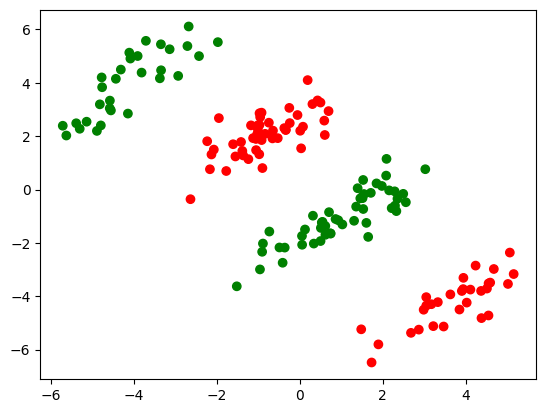

In [5]:
# 设置颜色参数
colors = {1:'r', -1:'g'}
# 绘制二分类数据集的散点图
plt.scatter(X_train[:,0], X_train[:,1], marker='o', c=pd.Series(y_train).map(colors))
plt.show();

In [6]:
svm = SVM(C = 100)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

     pcost       dcost       gap    pres   dres
 0:  8.2440e+04 -5.4800e+05  6e+05  6e-13  5e-13
 1:  2.5550e+04 -5.4529e+04  8e+04  3e-13  5e-13
 2:  4.5114e+03 -8.9010e+03  1e+04  4e-13  2e-13
 3:  5.0228e+02 -1.3352e+03  2e+03  5e-14  1e-13
 4: -3.9127e+01 -2.6009e+02  2e+02  7e-15  6e-14
 5: -9.3439e+01 -2.3707e+02  1e+02  2e-14  4e-14
 6: -1.6960e+02 -2.5187e+02  8e+01  4e-15  5e-14
 7: -1.9055e+02 -1.9894e+02  8e+00  2e-14  6e-14
 8: -1.9355e+02 -1.9386e+02  3e-01  4e-14  6e-14
 9: -1.9367e+02 -1.9367e+02  6e-03  2e-14  6e-14
10: -1.9367e+02 -1.9367e+02  2e-04  4e-14  6e-14
Optimal solution found.


In [7]:
print('Accuracy of soft margin svm based on cvxopt: ',
      accuracy_score(y_test, y_pred))

Accuracy of soft margin svm based on cvxopt:  1.0


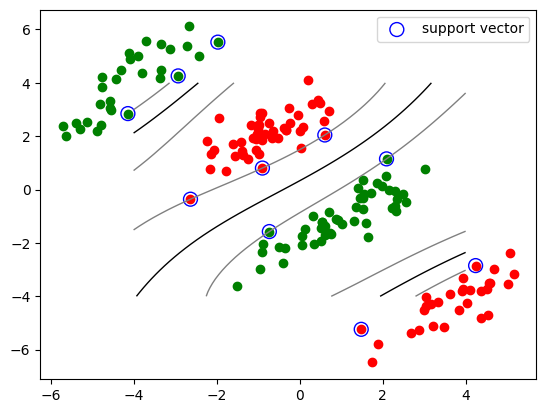

In [8]:
def plot_classifier(X1_train, X2_train, clf):
    plt.plot(X1_train[:,0], X1_train[:,1], "ro")
    plt.plot(X2_train[:,0], X2_train[:,1], "go")

    # 这里将 c="" 改为了 c="none"
    plt.scatter(clf.spv_X[:,0], clf.spv_X[:,1],
                s=100, c="none", edgecolors="b", label="support vector")

    X1, X2 = np.meshgrid(np.linspace(-4,4,50), np.linspace(-4,4,50))
    X = np.array([[x1, x2] for x1, x2 in zip(np.ravel(X1), np.ravel(X2))])
    Z = clf.project(X).reshape(X1.shape)

    plt.contour(X1, X2, Z, [0.0], colors='k', linewidths=1, origin='lower')
    plt.contour(X1, X2, Z + 1, [0.0], colors='grey', linewidths=1, origin='lower')
    plt.contour(X1, X2, Z - 1, [0.0], colors='grey', linewidths=1, origin='lower')
    plt.legend()
    plt.show()

plot_classifier(X_train[y_train==1], X_train[y_train==-1], svm)